# Era vs BERTTopic Comparison

Compares CUSUM-detected eras (from era_topic_analysis) with BERTTopic clusters.
Era detection is reproduced exactly from era_topic_analysis.py defaults.

In [166]:
import re
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import stumpy
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sqlalchemy import text

sys.path.insert(0, ".")
from models import engine

plt.rcParams["figure.dpi"] = 120

In [167]:
CHANNEL_QUERY   = "healthygamergg"
CONTENT_TYPE    = "long"
SHORTS_MAX_SECS = 180
PCA_DIMS        = 10
MP_WINDOW       = 25
SMOOTH_WINDOW   = 35
CUSUM_THRESHOLD = 6.0
CUSUM_DRIFT     = 0.5
CUSUM_MIN_SEP   = 40

In [168]:
_dur = {
    "long":  f"AND v.duration_seconds > {SHORTS_MAX_SECS}",
    "short": f"AND v.duration_seconds <= {SHORTS_MAX_SECS}",
    "all":   "",
}[CONTENT_TYPE]

_sql = f"""
    SELECT
        v.video_id, v.title, v.published_at, v.duration_seconds,
        avg(tc.embedding) AS mean_embedding
    FROM videos v
    JOIN channels c ON v.channel_id = c.channel_id
    JOIN transcript_chunks tc ON v.video_id = tc.video_id
    WHERE LOWER(c.title) LIKE LOWER('%{CHANNEL_QUERY}%')
      AND tc.embedding IS NOT NULL
      {_dur}
    GROUP BY v.video_id, v.title, v.published_at, v.duration_seconds
    ORDER BY v.published_at
"""

with engine.connect() as conn:
    r  = conn.execute(text(_sql))
    df = pd.DataFrame(r.fetchall(), columns=r.keys())

df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
print(f"Loaded {len(df)} videos")

Loaded 1021 videos


In [169]:
def _parse_emb(v):
    if isinstance(v, np.ndarray):
        return v.astype(float)
    if isinstance(v, (list, tuple)):
        return np.array(v, dtype=float)
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", str(v))
    return np.array(nums, dtype=float)

df["embedding"] = df["mean_embedding"].apply(_parse_emb)
emb      = np.stack(df["embedding"].values)
emb_norm = normalize(emb)

pca     = PCA(n_components=PCA_DIMS, random_state=42)
emb_pca = pca.fit_transform(emb_norm)

In [170]:
print("Computing matrix profiles...")
weights     = pca.explained_variance_ratio_ / pca.explained_variance_ratio_.sum()
n_profile   = len(df) - MP_WINDOW + 1
mp_combined = np.zeros(n_profile)

for dim in range(PCA_DIMS):
    mp_dim       = stumpy.stump(emb_pca[:, dim].astype(np.float64), m=MP_WINDOW)[:, 0].astype(float)
    mp_combined += weights[dim] * mp_dim

mp_z      = (mp_combined - mp_combined.mean()) / (mp_combined.std() + 1e-10)
mp_smooth = pd.Series(mp_z).rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().values
mp_smooth = (mp_smooth - mp_smooth.mean()) / (mp_smooth.std() + 1e-10)

S_pos, S_neg        = 0.0, 0.0
cusum_boundaries    = []
last_detection      = -CUSUM_MIN_SEP

for i, x in enumerate(mp_smooth):
    S_pos = max(0, S_pos + x - CUSUM_DRIFT)
    S_neg = max(0, S_neg - x - CUSUM_DRIFT)
    if S_pos > CUSUM_THRESHOLD or S_neg > CUSUM_THRESHOLD:
        if (i - last_detection) >= CUSUM_MIN_SEP:
            cusum_boundaries.append(i)
            last_detection = i
        S_pos, S_neg = 0.0, 0.0

boundary_indices = sorted([min(b, len(df) - 1) for b in cusum_boundaries])
era_slices       = list(zip([0] + boundary_indices, boundary_indices + [len(df)]))
n_eras           = len(era_slices)

df["era"] = -1
for era_num, (s, e) in enumerate(era_slices):
    df.iloc[s:e, df.columns.get_loc("era")] = era_num

df["era_label"] = df["era"].apply(
    lambda i: f"Era {i+1}\n({df.loc[df['era']==i, 'published_at'].dt.year.min()}–"
              f"{df.loc[df['era']==i, 'published_at'].dt.year.max()})"
    if i >= 0 else "?"
)

print(f"{n_eras} eras detected")
for i, (s, e) in enumerate(era_slices):
    print(f"  Era {i+1}: {df.iloc[s]['published_at'].date()} → {df.iloc[e-1]['published_at'].date()}  ({e-s} videos)")

Computing matrix profiles...
12 eras detected
  Era 1: 2019-01-25 → 2019-01-25  (7 videos)
  Era 2: 2019-01-25 → 2019-11-21  (43 videos)
  Era 3: 2019-11-21 → 2020-02-23  (61 videos)
  Era 4: 2020-02-24 → 2020-10-11  (91 videos)
  Era 5: 2020-10-16 → 2021-03-13  (43 videos)
  Era 6: 2021-03-15 → 2022-04-15  (202 videos)
  Era 7: 2022-04-16 → 2022-08-09  (94 videos)
  Era 8: 2022-08-10 → 2023-05-06  (130 videos)
  Era 9: 2023-05-09 → 2023-11-21  (70 videos)
  Era 10: 2023-11-24 → 2025-02-05  (134 videos)
  Era 11: 2025-02-10 → 2025-09-17  (81 videos)
  Era 12: 2025-09-22 → 2026-03-22  (65 videos)


In [171]:
# Run build_topic_labels.py first if this file doesn't exist
topics_df = pd.read_csv("video_topics_labeled.csv")  # video_id, topic, topic_label

topic_labels = dict(zip(topics_df["topic"], topics_df["topic_label"]))
topic_labels[-1] = "Outlier"

print(f"\nLoaded {len(topics_df)} video→topic assignments")


Loaded 2548 video→topic assignments


In [172]:
merged = df[["video_id", "published_at", "era", "era_label"]].merge(
    topics_df, on="video_id", how="inner"
)
print(f"\n{len(merged)} videos with both era and topic assignments")
print(f"  ({len(df) - len(merged)} era videos had no BERTTopic assignment — likely filtered out as empty noun docs)")


1021 videos with both era and topic assignments
  (0 era videos had no BERTTopic assignment — likely filtered out as empty noun docs)


In [173]:
merged_clean = merged[merged["topic"] != -1].copy()
ct_all = pd.crosstab(merged_clean["era"], merged_clean["topic"])
era_order_clean = sorted(ct_all.index)

top8_per_era = set()
for era in era_order_clean:
    top8_per_era.update(ct_all.loc[era].nlargest(8).index)

merged_clean["topic_label"] = merged_clean["topic"].apply(
    lambda t: topic_labels.get(t, f"Topic {t}") if t in top8_per_era else "Other"
)

era_short_labels = [
    f"Era {i+1}\n"
    f"{df.loc[df['era']==i, 'published_at'].dt.strftime('%b %y').iloc[0]}"
    f" – "
    f"{df.loc[df['era']==i, 'published_at'].dt.strftime('%b %y').iloc[-1]}"
    for i in era_order_clean
]

# Proportion table: era × topic_label, excluding Other
ct_labeled = pd.crosstab(merged_clean["era"], merged_clean["topic_label"])
ct_labeled = ct_labeled.reindex(era_order_clean).drop(columns=["Other"], errors="ignore")
pct_labeled = ct_labeled.div(ct_all.sum(axis=1), axis=0) * 100  # % of ALL era videos incl outliers
pct_labeled.index = era_short_labels

# Sort topics by total videos across all eras (row sum), largest first
topic_order = pct_labeled.sum(axis=0).sort_values(ascending=False).index.tolist()
pct_labeled = pct_labeled[topic_order]

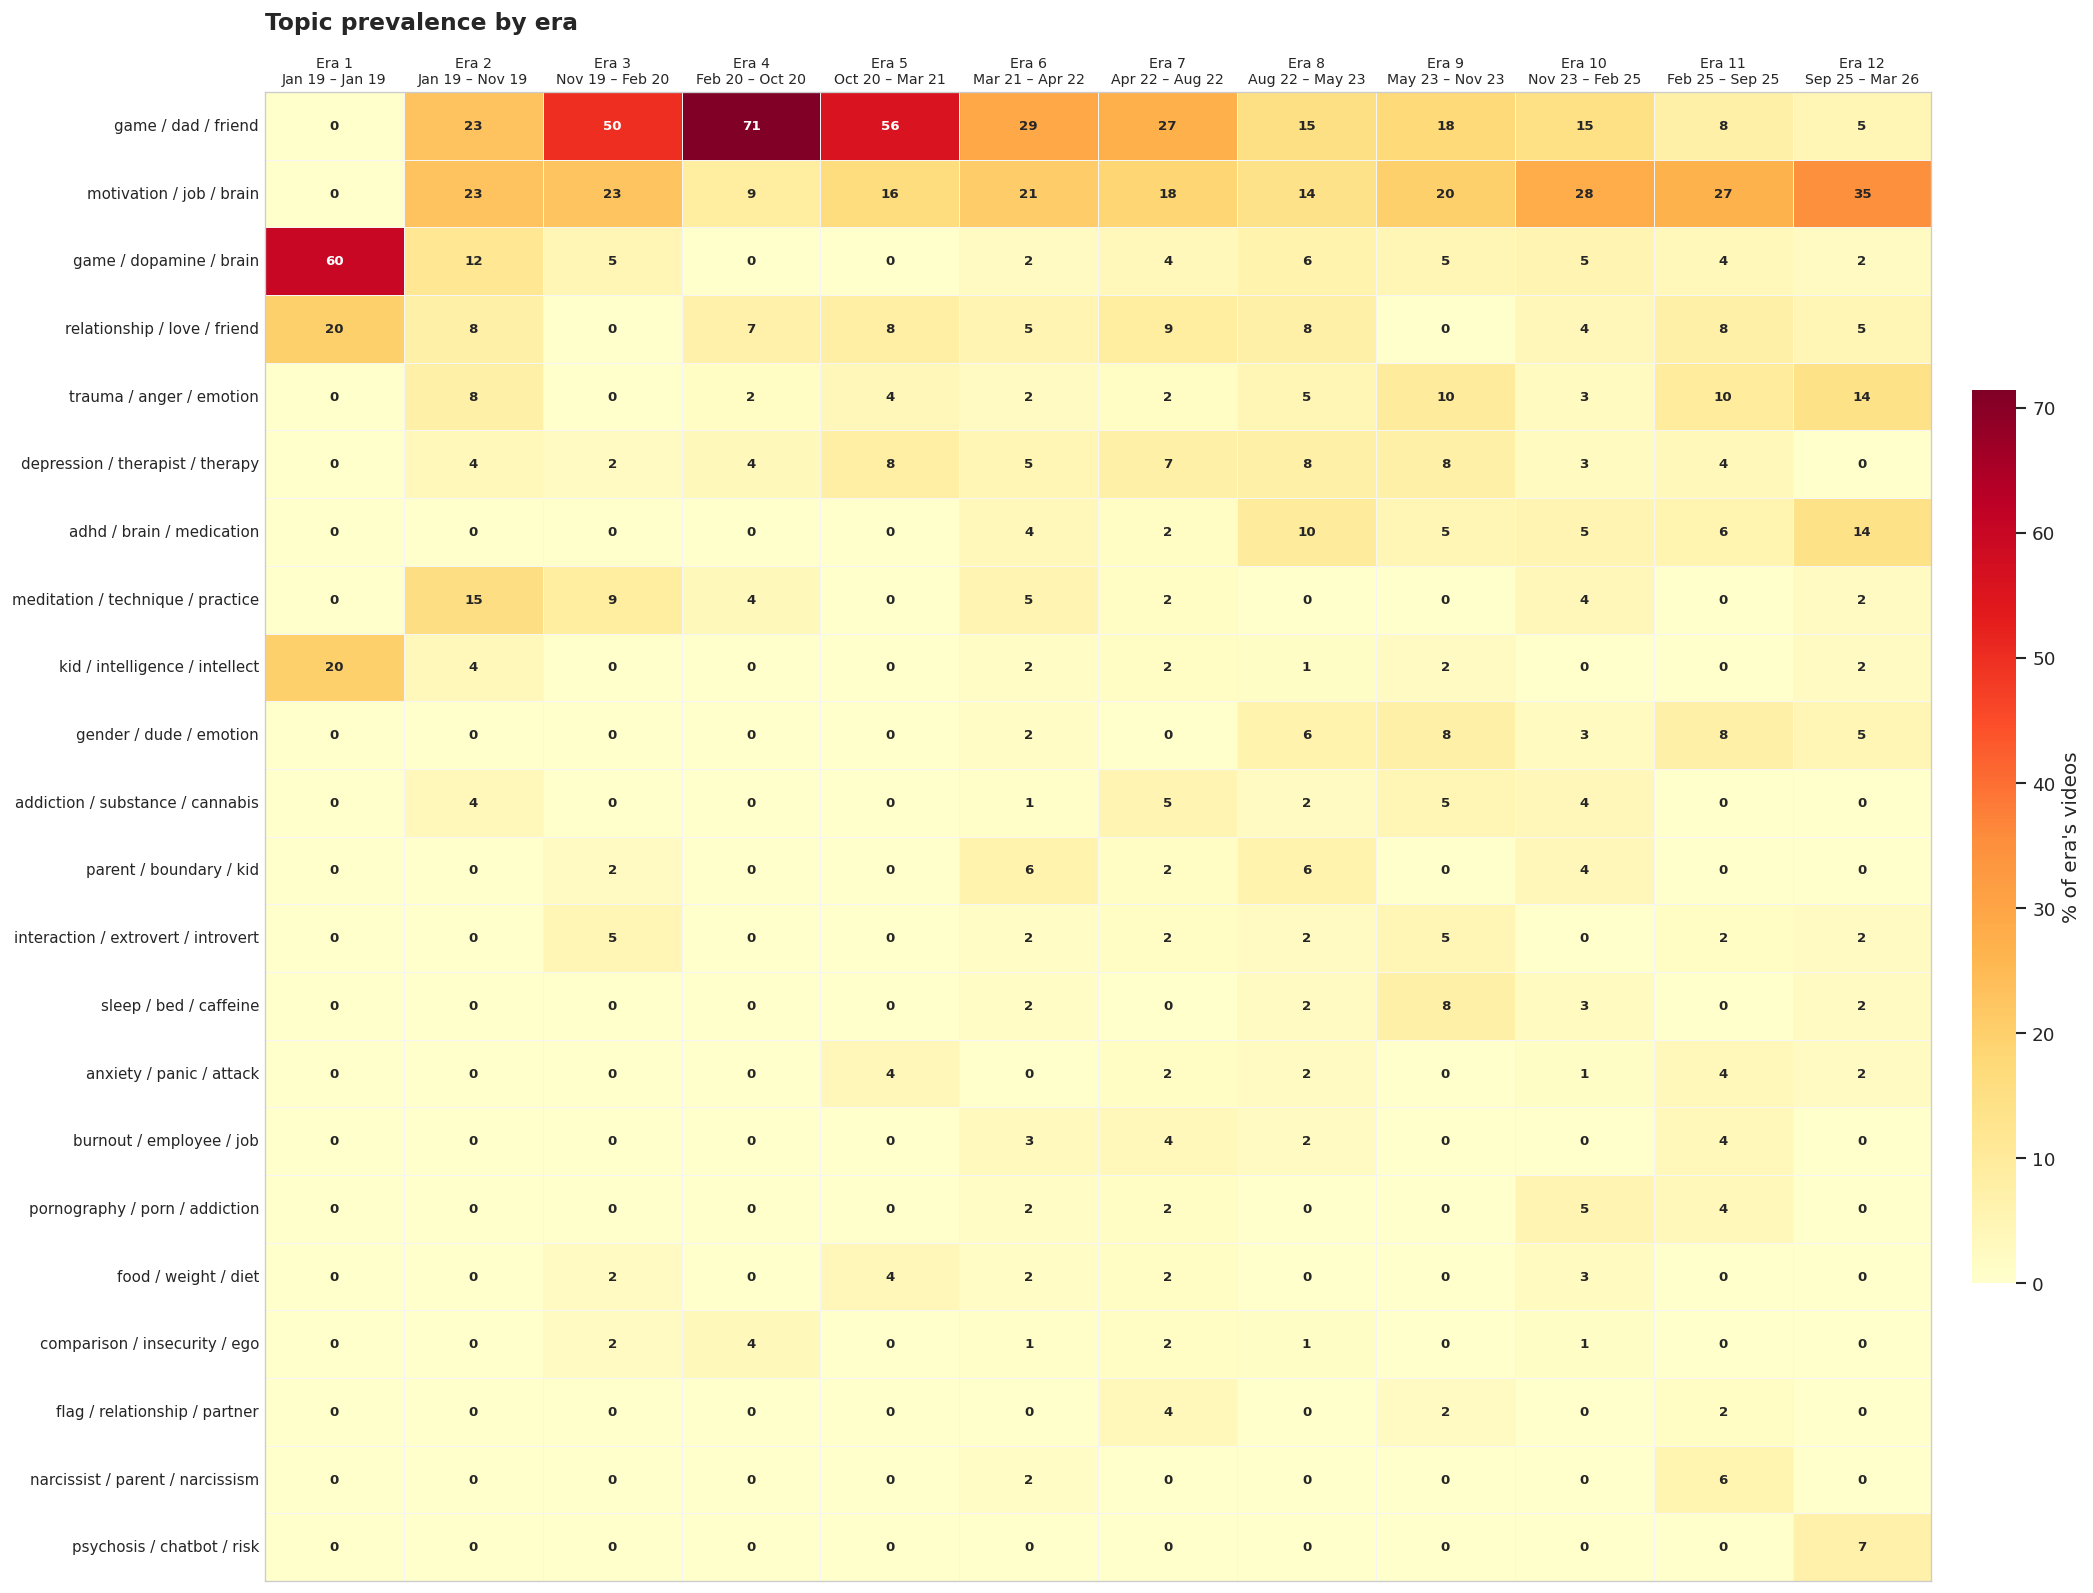

In [179]:
import seaborn as sns

n_topics = len(topic_order)
n_eras_c = len(era_short_labels)

sns.set_theme(style="white", font="DejaVu Sans")
fig, ax = plt.subplots(figsize=(n_eras_c * 1.6, n_topics * 0.52 + 2))

sns.heatmap(
    pct_labeled.T,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.6, linecolor="#f5f5f5",
    ax=ax,
    vmin=0,
    annot_kws={"size": 8, "weight": "bold"},
    cbar_kws={"label": "% of era's videos", "shrink": 0.6, "pad": 0.02},
)

ax.set_title("Topic prevalence by era", fontsize=14, fontweight="bold", pad=16, loc="left")

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=8.5, length=0)
ax.tick_params(axis="y", rotation=0, labelsize=9,   length=0)
ax.xaxis.tick_top()                          # era labels at top, easier to read
ax.xaxis.set_label_position("top")

# Thin border around whole chart
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_edgecolor("#cccccc")

plt.tight_layout()
plt.savefig("chart_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

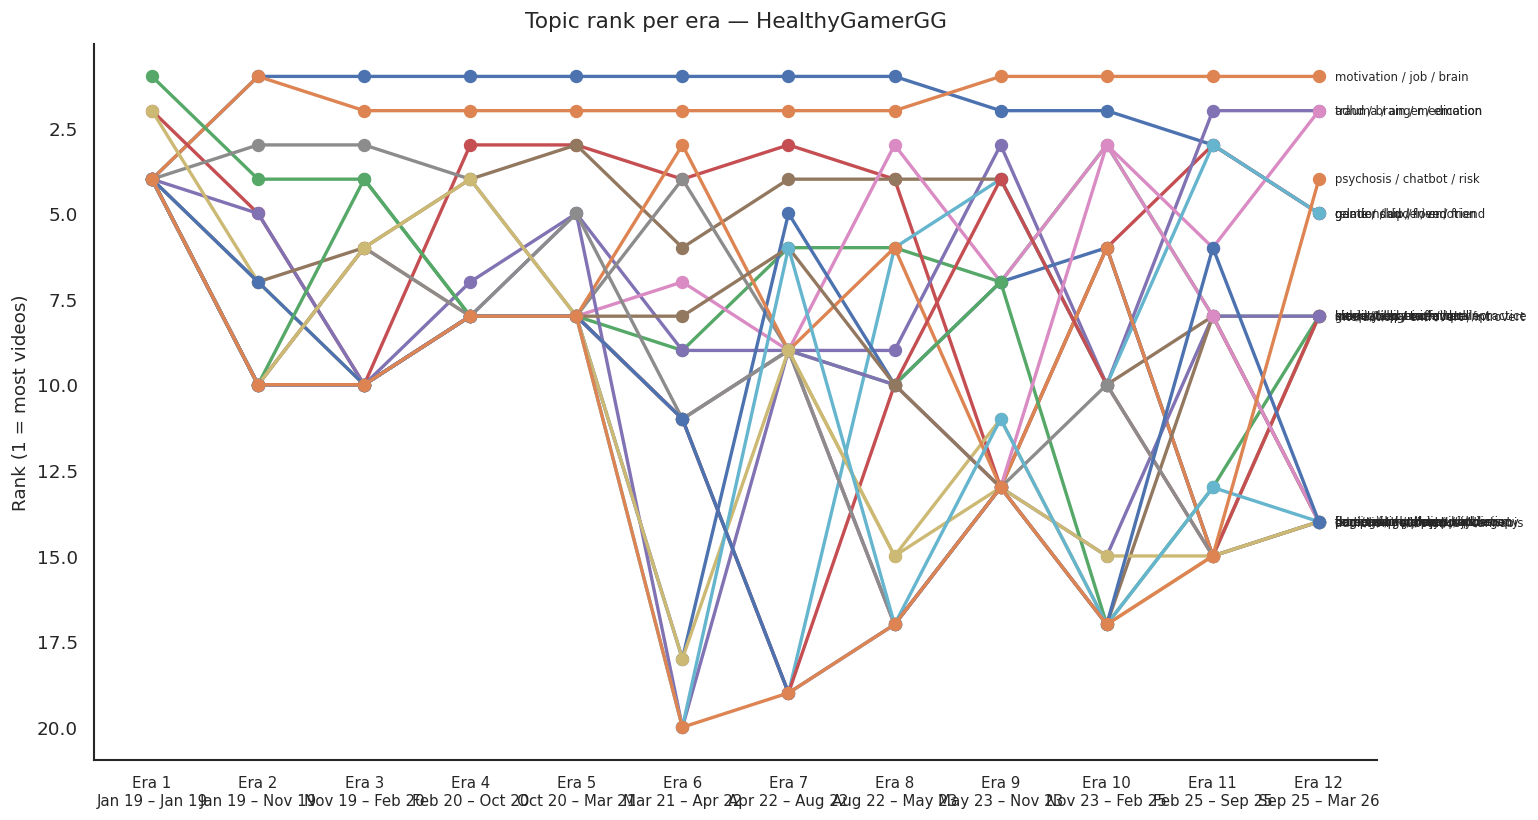

In [175]:
rank_df = pct_labeled.drop(columns=["Other"], errors="ignore").rank(
    axis=1, ascending=False, method="min"
)
topics_to_plot = [c for c in rank_df.columns]

fig, ax = plt.subplots(figsize=(13, 7))
for topic in topics_to_plot:
    ys = rank_df[topic].values
    xs = range(len(era_short_labels))
    ax.plot(xs, ys, marker="o", linewidth=2, markersize=7, label=topic)
    ax.text(len(era_short_labels) - 0.85, ys[-1], topic, va="center", fontsize=7)

ax.set_xticks(range(len(era_short_labels)))
ax.set_xticklabels(era_short_labels, fontsize=9)
ax.invert_yaxis()
ax.set_ylabel("Rank (1 = most videos)", fontsize=11)
ax.set_title("Topic rank per era — HealthyGamerGG", fontsize=13, pad=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("chart_bump.png", bbox_inches="tight", dpi=150)
plt.show()

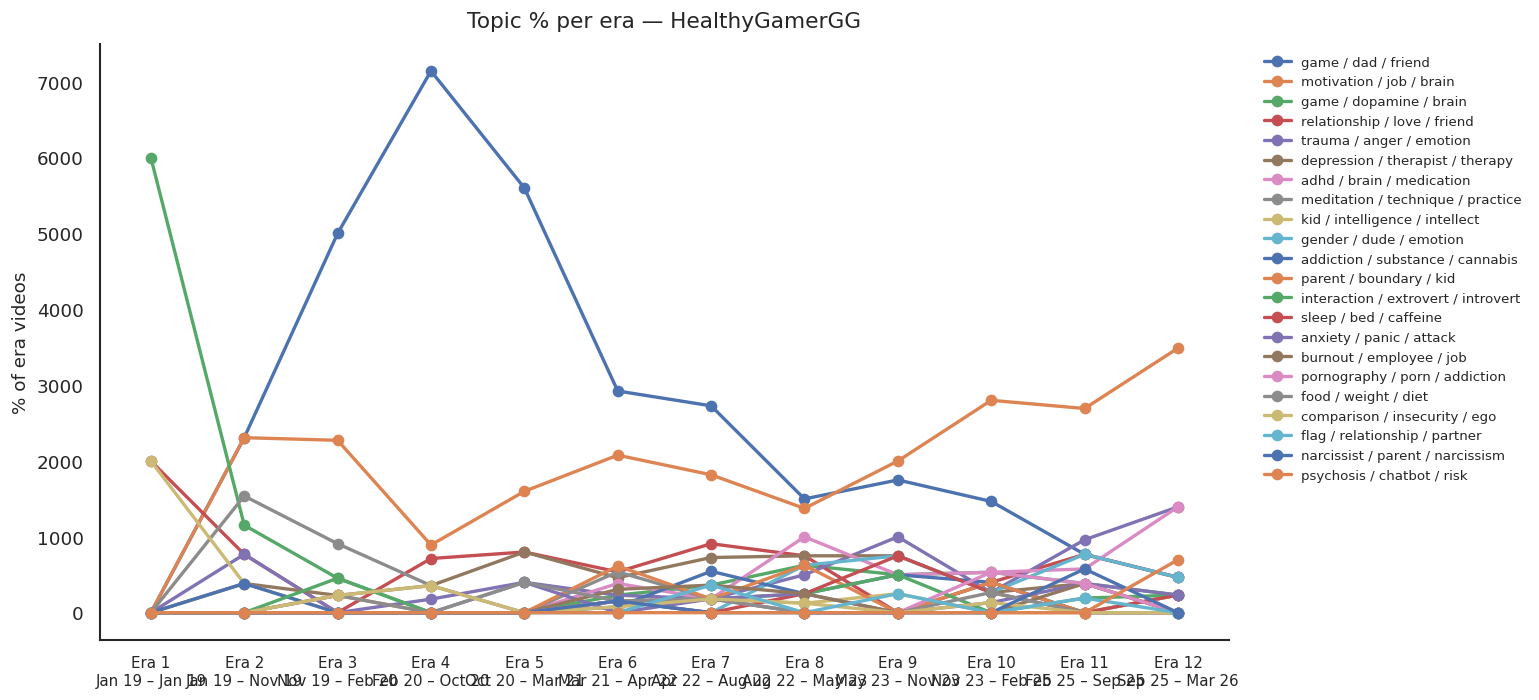

In [176]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_cols = [c for c in pct_labeled.columns if c != "Other"]
for topic in plot_cols:
    ys = pct_labeled[topic].values * 100
    xs = range(len(era_short_labels))
    ax.plot(xs, ys, marker="o", linewidth=2, markersize=6, label=topic)

ax.set_xticks(range(len(era_short_labels)))
ax.set_xticklabels(era_short_labels, fontsize=9)
ax.set_ylabel("% of era videos", fontsize=11)
ax.set_title("Topic % per era — HealthyGamerGG", fontsize=13, pad=10)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("chart_lines.png", bbox_inches="tight", dpi=150)
plt.show()

In [177]:
print("\n=== DOMINANT TOPIC PER ERA ===\n")
for era_num in era_order:
    row = ct.loc[era_num]
    top3 = row.sort_values(ascending=False).head(3)
    total = row.sum()
    label = era_date_labels[era_num].replace("\n", " ")
    parts = [f"{topic_labels.get(t, f'Topic {t}')} ({v} vids, {v/total*100:.0f}%)" for t, v in top3.items()]
    print(f"{label}: {' | '.join(parts)}")


=== DOMINANT TOPIC PER ERA ===

Era 1  2019-01-25 → 2019-01-25: motivation / job / brain (3 vids, 60%) | addiction / substance / cannabis (1 vids, 20%) | Topic 43 (1 vids, 20%)
Era 2  2019-01-25 → 2019-11-21: meditation / technique / practice (4 vids, 15%) | motivation / job / brain (3 vids, 12%) | adhd / brain / medication (3 vids, 12%)
Era 3  2019-11-21 → 2020-02-23: game / dopamine / brain (9 vids, 20%) | adhd / brain / medication (8 vids, 18%) | meditation / technique / practice (4 vids, 9%)
Era 4  2020-02-24 → 2020-10-11: game / dopamine / brain (18 vids, 32%) | adhd / brain / medication (4 vids, 7%) | addiction / substance / cannabis (4 vids, 7%)
Era 5  2020-10-16 → 2021-03-13: game / dopamine / brain (8 vids, 32%) | relationship / love / friend (2 vids, 8%) | addiction / substance / cannabis (2 vids, 8%)
Era 6  2021-03-15 → 2022-04-15: game / dopamine / brain (10 vids, 8%) | adhd / brain / medication (9 vids, 7%) | burnout / employee / job (7 vids, 5%)
Era 7  2022-04-16 → 2022-

In [178]:
print("\n=== TOPIC SPREAD ACROSS ERAS ===\n")
for topic in sorted(merged["topic"].unique()):
    if topic == -1:
        continue
    sub = merged[merged["topic"] == topic]
    era_counts = sub["era"].value_counts().sort_index()
    dominant_era = era_counts.idxmax() + 1
    pct_in_dominant = era_counts.max() / len(sub) * 100
    print(f"Topic {topic:3d} ({len(sub):4d} videos): "
          f"mostly Era {dominant_era} ({pct_in_dominant:.0f}%)  — "
          f"spread across {era_counts[era_counts > 0].count()}/{n_eras} eras")


=== TOPIC SPREAD ACROSS ERAS ===

Topic   0 ( 131 videos): mostly Era 6 (21%)  — spread across 11/12 eras
Topic   1 ( 171 videos): mostly Era 4 (23%)  — spread across 11/12 eras
Topic   2 (  27 videos): mostly Era 8 (19%)  — spread across 10/12 eras
Topic   3 (  29 videos): mostly Era 12 (21%)  — spread across 10/12 eras
Topic   4 (  36 videos): mostly Era 6 (19%)  — spread across 10/12 eras
Topic   5 (  29 videos): mostly Era 8 (28%)  — spread across 7/12 eras
Topic   6 (  18 videos): mostly Era 8 (28%)  — spread across 6/12 eras
Topic   7 (  29 videos): mostly Era 6 (21%)  — spread across 10/12 eras
Topic   8 (  11 videos): mostly Era 3 (18%)  — spread across 7/12 eras
Topic   9 (  18 videos): mostly Era 6 (44%)  — spread across 5/12 eras
Topic  10 (  12 videos): mostly Era 7 (25%)  — spread across 6/12 eras
Topic  11 (  10 videos): mostly Era 9 (30%)  — spread across 5/12 eras
Topic  12 (  22 videos): mostly Era 6 (32%)  — spread across 7/12 eras
Topic  13 (   7 videos): mostly Era